# Projeto de Machine Learning — Risco de Crédito

Este notebook apresenta o desenvolvimento de um pipeline de Machine Learning para previsão de risco de crédito.

A base escolhida foi a **Opção A — Risco de Crédito**, cujo objetivo é prever se um cliente poderá se tornar inadimplente ou se pagará o empréstimo em dia.

A variável alvo do projeto é `loan_status`, onde:

- `0` representa cliente pagador;
- `1` representa cliente inadimplente.



## Etapas do projeto

O projeto será organizado nas seguintes fases:

1. **Análise Exploratória de Dados (EDA)**
2. **Tratamento e Limpeza dos Dados**
3. **Feature Engineering**
4. **Separação, Balanceamento e Escalonamento Seguro**
5. **Modelagem com KNN e Árvore de Decisão**
6. **Avaliação Final e Veredito de Negócio**

Além do código, cada etapa contém explicações em Markdown para deixar o notebook adequado a uma entrega acadêmica.

## 0. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas utilizadas para manipulação dos dados, visualização, preparação, balanceamento, modelagem e avaliação dos modelos.

In [1]:
# Bibliotecas principais para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para trabalhar com caminhos de arquivos
from pathlib import Path

# Configuração para exibir mais colunas no notebook
pd.set_option("display.max_columns", None)

# Configuração visual padrão dos gráficos
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Definindo o caminho da base de dados
# O código abaixo funciona tanto se o notebook estiver sendo executado da raiz do projeto
# quanto se estiver sendo executado diretamente da pasta notebooks.

base_dir = Path.cwd()

if (base_dir / "data" / "credit_risk_dataset.csv").exists():
    caminho_csv = base_dir / "data" / "credit_risk_dataset.csv"
else:
    caminho_csv = base_dir.parent / "data" / "credit_risk_dataset.csv"

# Carregando a base de dados
df = pd.read_csv(caminho_csv)

# Exibindo as primeiras linhas da base
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Verificando o tamanho da base de dados
linhas, colunas = df.shape

print(f"A base possui {linhas} linhas e {colunas} colunas.")

A base possui 32581 linhas e 12 colunas.


In [4]:
# Visualizando informações gerais da base:
# - nome das colunas
# - quantidade de valores não nulos
# - tipo de dado de cada variável

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
# Listando todas as colunas disponíveis na base
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

## 1.1 Carregamento inicial da base

Nesta etapa foi realizada a importação das principais bibliotecas utilizadas no projeto e o carregamento da base `credit_risk_dataset.csv`.

Também foi feita uma verificação inicial do tamanho da base, dos tipos de dados e das primeiras linhas do conjunto de dados. Essa análise inicial é importante para compreender a estrutura do problema antes de aplicar qualquer tratamento, transformação ou modelo de Machine Learning.

## 1.2 Análise descritiva inicial

Nesta etapa será realizada uma análise descritiva da base de dados, com o objetivo de compreender melhor a estrutura das variáveis, identificar valores ausentes, verificar duplicidades e analisar a distribuição da variável alvo `loan_status`.

Essa etapa é importante porque decisões de limpeza, tratamento de nulos, tratamento de outliers e balanceamento dependem diretamente do comportamento inicial dos dados.

In [6]:
# Estatísticas descritivas das variáveis numéricas
# O .T é utilizado apenas para transpor a tabela e facilitar a leitura no notebook.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [7]:
# Estatísticas descritivas das variáveis categóricas
# include="object" seleciona apenas colunas textuais/categóricas.

df.describe(include="object").T

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15356\3442359427.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [8]:
# Verificando a quantidade e o percentual de valores nulos em cada coluna

nulos = pd.DataFrame({
    "quantidade_nulos": df.isnull().sum(),
    "percentual_nulos": (df.isnull().mean() * 100).round(2)
})

nulos = nulos[nulos["quantidade_nulos"] > 0].sort_values(
    by="quantidade_nulos",
    ascending=False
)

nulos

,quantidade_nulos,percentual_nulos
loan_int_rate,3116,9.56
person_emp_length,895,2.75


In [9]:
# Verificando a quantidade de linhas duplicadas na base

quantidade_duplicadas = df.duplicated().sum()

print(f"A base possui {quantidade_duplicadas} linhas duplicadas.")

A base possui 165 linhas duplicadas.


In [10]:
# Verificando a distribuição absoluta e percentual da variável alvo loan_status

distribuicao_alvo = pd.DataFrame({
    "quantidade": df["loan_status"].value_counts(),
    "percentual": (df["loan_status"].value_counts(normalize=True) * 100).round(2)
})

distribuicao_alvo.index = ["Pagador - Classe 0", "Inadimplente - Classe 1"]

distribuicao_alvo

,quantidade,percentual
Pagador - Classe 0,25473,78.18
Inadimplente - Classe 1,7108,21.82


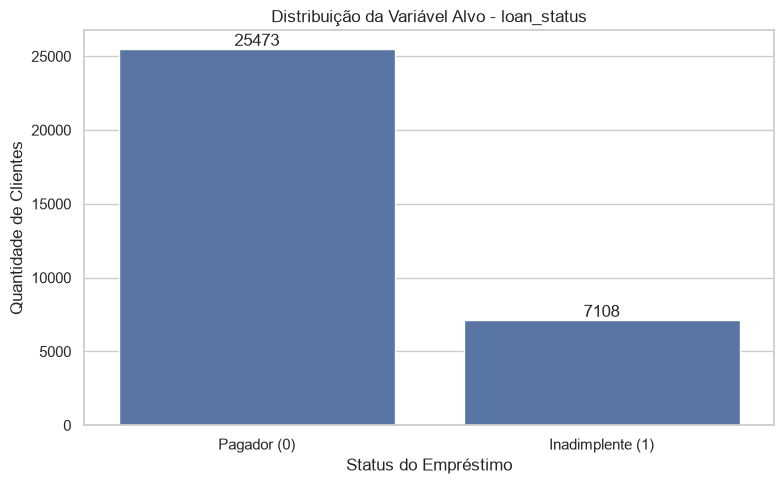

In [11]:
# Gráfico de barras para visualizar o desbalanceamento da variável alvo

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Distribuição da Variável Alvo - loan_status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade de Clientes")
plt.xticks(
    ticks=[0, 1],
    labels=["Pagador (0)", "Inadimplente (1)"]
)

# Adicionando os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

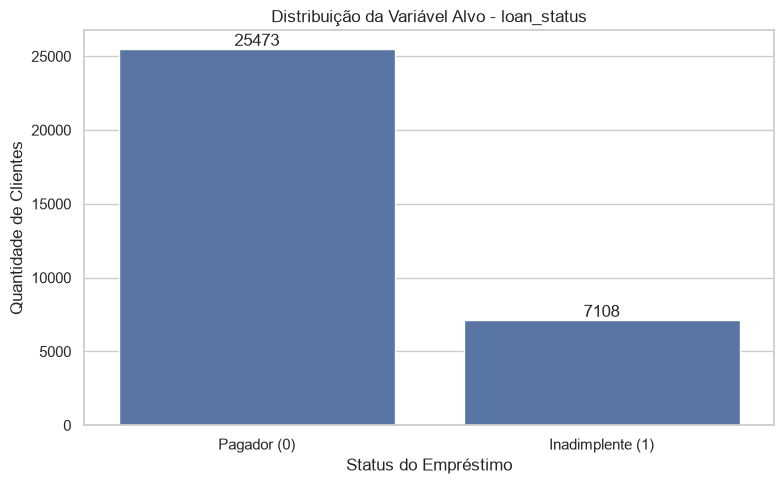

In [12]:
# Salvando o gráfico da variável alvo para uso posterior no README.md

caminho_grafico_alvo = Path("../imagens/graficos_eda/distribuicao_variavel_alvo.png")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Distribuição da Variável Alvo - loan_status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade de Clientes")
plt.xticks(
    ticks=[0, 1],
    labels=["Pagador (0)", "Inadimplente (1)"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(caminho_grafico_alvo, dpi=300, bbox_inches="tight")
plt.show()

## 1.3 Interpretação inicial da análise descritiva

A análise descritiva inicial mostrou que a base possui variáveis numéricas e categóricas relacionadas ao perfil do cliente, características do empréstimo e histórico de crédito.

Foram identificados valores ausentes em variáveis importantes, como `person_emp_length` e `loan_int_rate`, que precisarão ser tratados na etapa de preparação dos dados. Também foram encontradas linhas duplicadas, que serão removidas na fase de limpeza para evitar redundância no treinamento dos modelos.

A distribuição da variável alvo `loan_status` indica desbalanceamento entre as classes, com maior quantidade de clientes pagadores em comparação aos inadimplentes. Isso mostra que será necessário aplicar uma técnica de balanceamento somente nos dados de treino, evitando vazamento de dados para a base de teste.

Também é possível observar indícios de valores extremos em algumas variáveis numéricas, como idade, renda e tempo de emprego. Esses pontos serão avaliados com gráficos de boxplot antes da decisão final de tratamento dos outliers.

## 1.4 Análise visual dos dados

Nesta etapa serão criados gráficos para compreender melhor a distribuição das variáveis numéricas, identificar possíveis outliers e observar relações entre variáveis por meio da correlação de Pearson.

A análise visual complementa a análise estatística, pois permite identificar padrões que nem sempre ficam claros apenas com tabelas.

In [14]:
# Definindo a raiz do projeto de forma segura
# Isso evita erro caso o notebook seja executado da raiz do projeto ou da pasta notebooks.

base_dir = Path.cwd()

if (base_dir / "data").exists():
    raiz_projeto = base_dir
else:
    raiz_projeto = base_dir.parent

# Pasta onde os gráficos da EDA serão salvos
pasta_graficos = raiz_projeto / "imagens" / "graficos_eda"
pasta_graficos.mkdir(parents=True, exist_ok=True)

pasta_graficos

WindowsPath('c:/Users/USUARIO/Documents/CURSO SCTEC/projeto final modulo 1/projeto-risco-credito-machine-learning/imagens/graficos_eda')

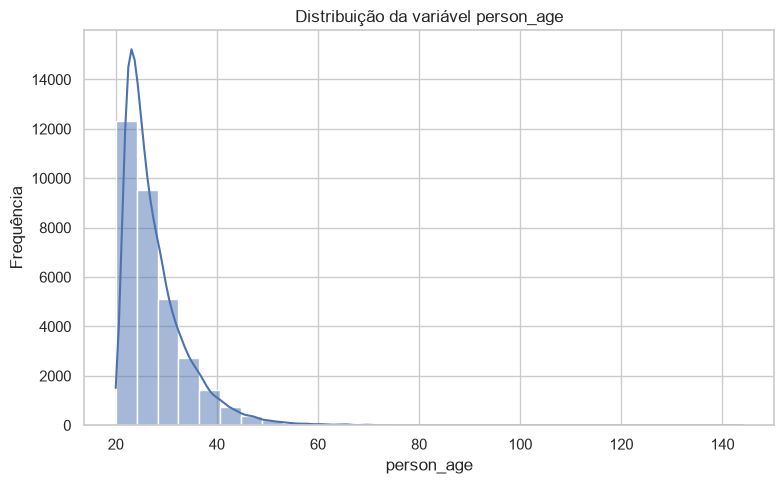

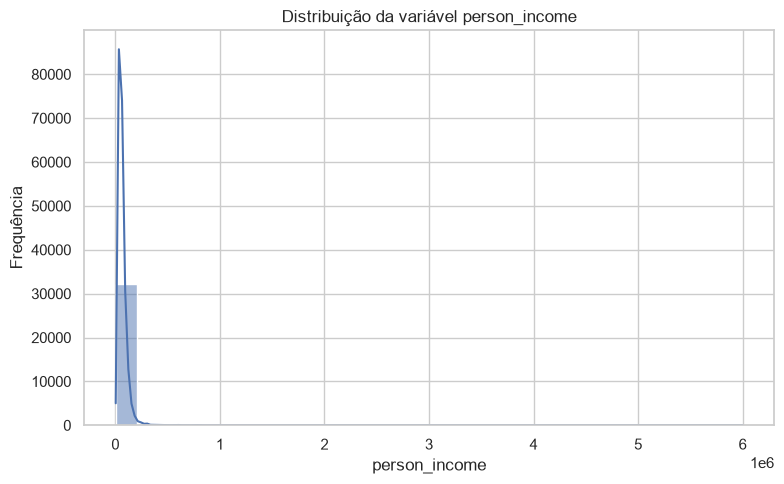

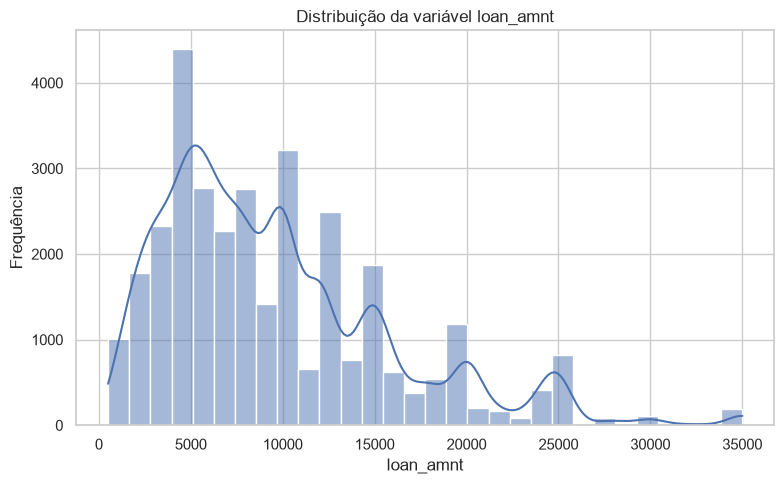

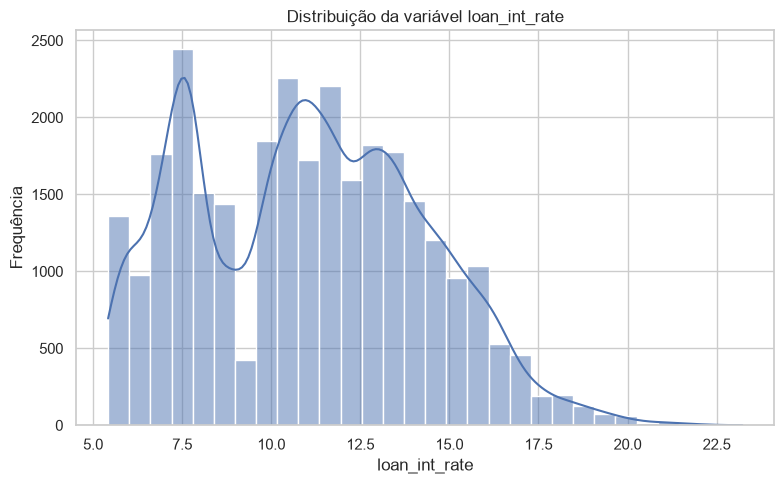

In [15]:
# Histogramas para analisar a distribuição de variáveis numéricas importantes

variaveis_histograma = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate"
]

for coluna in variaveis_histograma:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=coluna,
        kde=True,
        bins=30
    )
    
    plt.title(f"Distribuição da variável {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    
    plt.savefig(
        pasta_graficos / f"histograma_{coluna}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

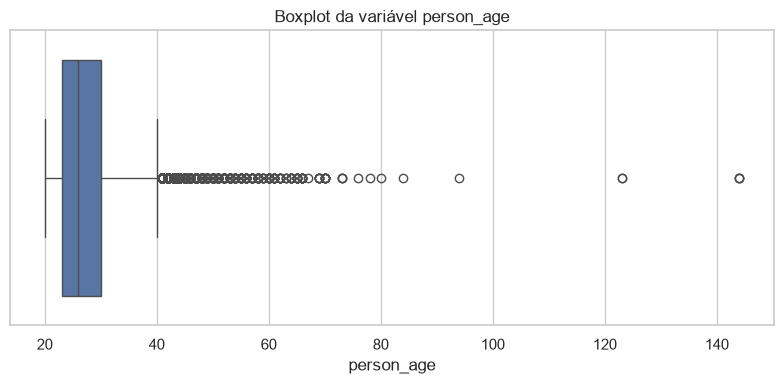

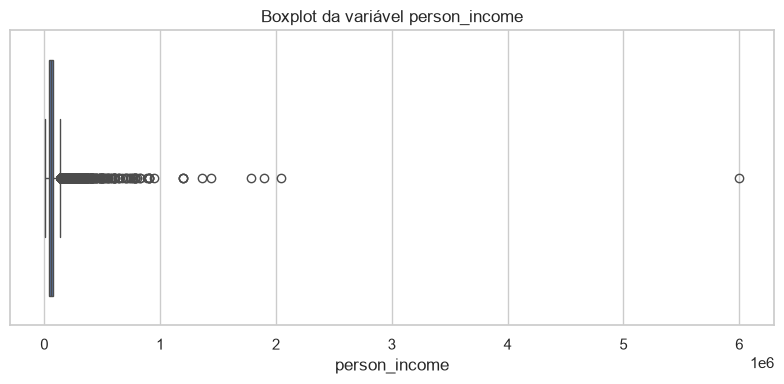

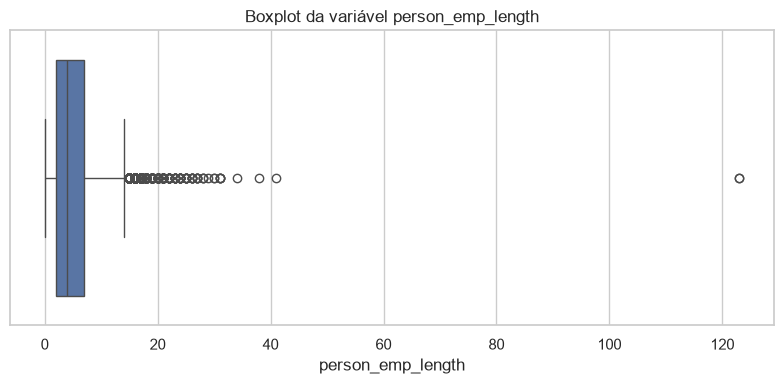

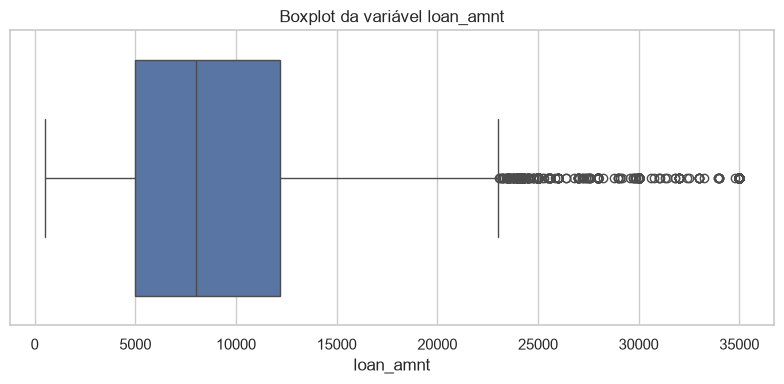

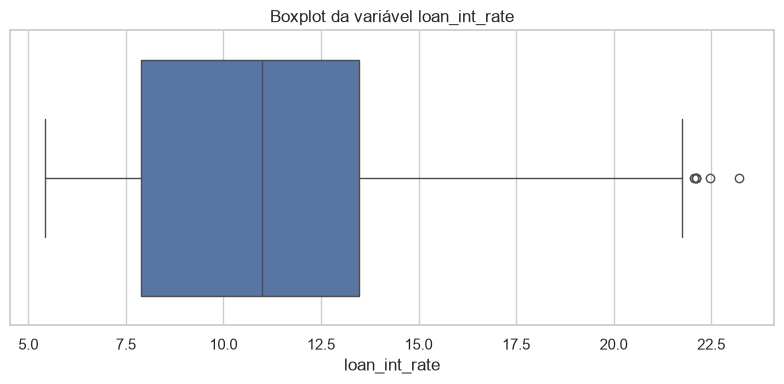

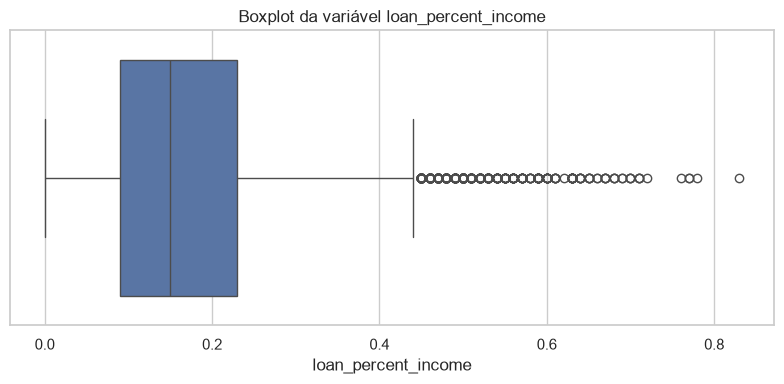

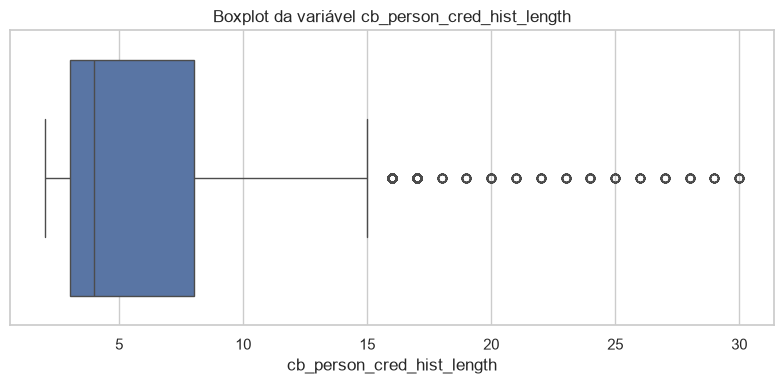

In [16]:
# Boxplots para identificar possíveis valores extremos nas variáveis numéricas

variaveis_boxplot = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for coluna in variaveis_boxplot:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=coluna
    )
    
    plt.title(f"Boxplot da variável {coluna}")
    plt.xlabel(coluna)
    plt.tight_layout()
    
    plt.savefig(
        pasta_graficos / f"boxplot_{coluna}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [17]:
# Selecionando apenas as variáveis numéricas para análise de correlação

df_numerico = df.select_dtypes(include=["int64", "float64"])

correlacao = df_numerico.corr(method="pearson")

correlacao

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


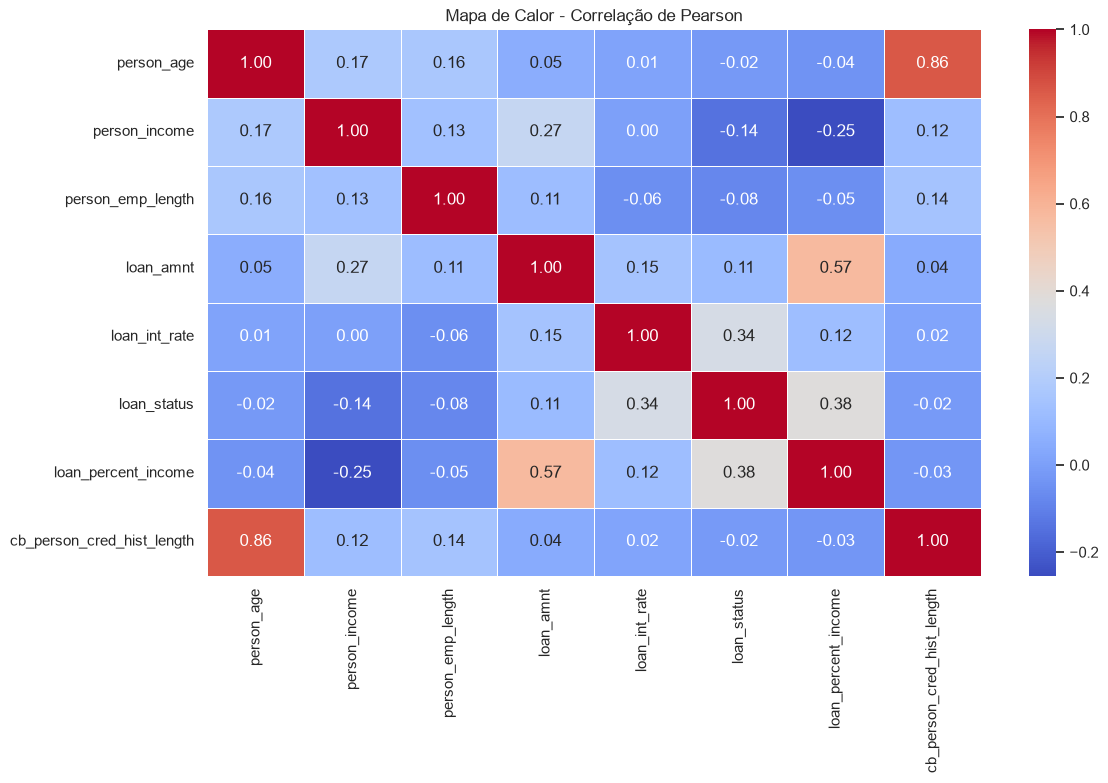

In [18]:
# Mapa de calor de correlação de Pearson

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de Calor - Correlação de Pearson")
plt.tight_layout()

plt.savefig(
    pasta_graficos / "mapa_calor_correlacao_pearson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Correlação das variáveis numéricas com a variável alvo loan_status

correlacao_alvo = correlacao["loan_status"].sort_values(ascending=False)

correlacao_alvo

loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.335133
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082489
person_income                -0.144449
Name: loan_status, dtype: float64

## 1.5 Interpretação da análise visual

A análise visual reforçou alguns pontos importantes sobre a base de risco de crédito.

Primeiro, a variável alvo `loan_status` apresenta desbalanceamento, com maior concentração de clientes pagadores em relação aos inadimplentes. Esse comportamento confirma a necessidade de aplicar uma técnica de balanceamento apenas nos dados de treino, evitando vazamento de dados para a base de teste.

Os histogramas indicam que algumas variáveis financeiras, como `person_income`, `loan_amnt` e `loan_int_rate`, podem apresentar distribuições assimétricas. Esse comportamento sugere que a mediana tende a ser uma escolha mais segura do que a média para imputação de valores ausentes, pois sofre menos influência de valores extremos.

Os boxplots mostram possíveis outliers em variáveis como idade, renda, tempo de emprego e valor do empréstimo. Esses valores precisam ser analisados com cuidado, pois podem representar tanto erros ou registros incomuns quanto clientes reais com características extremas. Essa decisão será tomada na etapa de tratamento dos dados.

O mapa de calor de correlação de Pearson permite observar as relações lineares entre variáveis numéricas. Variáveis relacionadas ao valor do empréstimo, percentual da renda comprometida e histórico de crédito podem influenciar o comportamento da variável alvo. No entanto, a correlação não deve ser interpretada como causalidade, mas sim como um apoio para compreender padrões iniciais da base.

## 1.6 Conclusão da Análise Exploratória

A Análise Exploratória de Dados permitiu identificar características importantes da base de risco de crédito antes da etapa de modelagem.

A base possui variáveis numéricas e categóricas relacionadas ao perfil do cliente, ao empréstimo solicitado e ao histórico de crédito. A variável alvo `loan_status` apresenta desbalanceamento, com maior quantidade de clientes pagadores do que inadimplentes. Esse ponto é relevante porque modelos treinados em bases desbalanceadas podem aprender a favorecer a classe majoritária, prejudicando a identificação de clientes inadimplentes.

Também foram encontrados valores ausentes nas colunas `person_emp_length` e `loan_int_rate`. Como as variáveis financeiras e de perfil apresentaram assimetria e possíveis valores extremos, a mediana será utilizada na etapa de imputação, pois é menos sensível a outliers do que a média.

Os boxplots indicaram a presença de valores discrepantes em variáveis como idade, renda, tempo de emprego, valor do empréstimo e histórico de crédito. Como o KNN é sensível a outliers por trabalhar com distância entre pontos, esses valores precisam ser tratados com cuidado. Já a Árvore de Decisão tende a ser mais robusta a valores extremos, pois realiza divisões por regras e cortes nas variáveis.

Dessa forma, as decisões da próxima etapa serão:

- remover linhas duplicadas;
- imputar valores ausentes com mediana;
- aplicar tratamento de outliers por clipping, preservando registros e reduzindo o impacto de valores extremos;
- preparar a base para a criação da nova variável `comprometimento_renda`.

# 2. Tratamento e Limpeza dos Dados

Nesta fase serão aplicados os principais tratamentos necessários antes da modelagem.

As ações realizadas serão:

1. criação de uma cópia da base original;
2. remoção de linhas duplicadas;
3. tratamento de valores nulos;
4. identificação e tratamento de outliers.

A base original será preservada na variável `df`, enquanto a base tratada será armazenada em `df_tratado`.

In [20]:
# Criando uma cópia da base original para realizar os tratamentos
# A base original permanece preservada na variável df.

df_tratado = df.copy()

print("Base original:", df.shape)
print("Base para tratamento:", df_tratado.shape)

Base original: (32581, 12)
Base para tratamento: (32581, 12)


In [21]:
# Verificando a quantidade de duplicadas antes da remoção

duplicadas_antes = df_tratado.duplicated().sum()

print(f"Quantidade de linhas duplicadas antes do tratamento: {duplicadas_antes}")

Quantidade de linhas duplicadas antes do tratamento: 165


In [22]:
# Removendo linhas duplicadas

df_tratado = df_tratado.drop_duplicates().reset_index(drop=True)

duplicadas_depois = df_tratado.duplicated().sum()

print(f"Quantidade de linhas duplicadas depois do tratamento: {duplicadas_depois}")
print(f"Novo tamanho da base: {df_tratado.shape}")

Quantidade de linhas duplicadas depois do tratamento: 0
Novo tamanho da base: (32416, 12)


## 2.1 Tratamento de linhas duplicadas

As linhas duplicadas foram removidas para evitar redundância na base de dados.

A permanência de registros duplicados poderia fazer com que alguns padrões fossem considerados mais vezes durante o treinamento, influenciando o aprendizado dos modelos e gerando uma avaliação menos confiável.

In [23]:
# Verificando valores nulos após a remoção de duplicadas

nulos_antes = pd.DataFrame({
    "quantidade_nulos": df_tratado.isnull().sum(),
    "percentual_nulos": (df_tratado.isnull().mean() * 100).round(2)
})

nulos_antes = nulos_antes[nulos_antes["quantidade_nulos"] > 0].sort_values(
    by="quantidade_nulos",
    ascending=False
)

nulos_antes

,quantidade_nulos,percentual_nulos
loan_int_rate,3095,9.55
person_emp_length,887,2.74


In [24]:
# Comparando média e mediana das colunas com valores nulos

colunas_com_nulos = ["person_emp_length", "loan_int_rate"]

comparacao_media_mediana = pd.DataFrame({
    "media": df_tratado[colunas_com_nulos].mean(),
    "mediana": df_tratado[colunas_com_nulos].median(),
    "desvio_padrao": df_tratado[colunas_com_nulos].std(),
    "minimo": df_tratado[colunas_com_nulos].min(),
    "maximo": df_tratado[colunas_com_nulos].max()
})

comparacao_media_mediana

,media,mediana,desvio_padrao,minimo,maximo
person_emp_length,4.790510,4.00,4.14549,0.00,123.00
loan_int_rate,11.017265,10.99,3.24168,5.42,23.22


In [25]:
# Imputando valores nulos com a mediana
# A mediana foi escolhida por ser mais robusta a distribuições assimétricas e valores extremos.

for coluna in colunas_com_nulos:
    mediana = df_tratado[coluna].median()
    df_tratado[coluna] = df_tratado[coluna].fillna(mediana)
    
    print(f"Coluna {coluna}: nulos preenchidos com a mediana = {mediana}")

Coluna person_emp_length: nulos preenchidos com a mediana = 4.0
Coluna loan_int_rate: nulos preenchidos com a mediana = 10.99


In [26]:
# Conferindo se ainda existem valores nulos

df_tratado.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [27]:
# Função para calcular outliers pelo método IQR

def calcular_outliers_iqr(dataframe, coluna):
    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    quantidade_outliers = (
        (dataframe[coluna] < limite_inferior) |
        (dataframe[coluna] > limite_superior)
    ).sum()
    
    percentual_outliers = (quantidade_outliers / len(dataframe)) * 100
    
    return limite_inferior, limite_superior, quantidade_outliers, percentual_outliers

In [28]:
# Identificando outliers nas variáveis numéricas preditoras

colunas_numericas_outliers = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

resultado_outliers = []

for coluna in colunas_numericas_outliers:
    limite_inferior, limite_superior, quantidade, percentual = calcular_outliers_iqr(
        df_tratado,
        coluna
    )
    
    resultado_outliers.append({
        "coluna": coluna,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "quantidade_outliers": quantidade,
        "percentual_outliers": round(percentual, 2)
    })

df_outliers = pd.DataFrame(resultado_outliers)

df_outliers

,coluna,limite_inferior,limite_superior,quantidade_outliers,percentual_outliers
0,person_age,12.50,40.50,1491,4.60
1,person_income,-22472.00,140232.00,1478,4.56
2,person_emp_length,-5.50,14.50,852,2.63
3,loan_amnt,-5875.00,23125.00,1679,5.18
4,loan_int_rate,1.56,20.04,70,0.22
5,loan_percent_income,-0.12,0.44,650,2.01
6,cb_person_cred_hist_length,-4.50,15.50,1139,3.51


In [29]:
# Aplicando clipping nos outliers
# O objetivo é reduzir o impacto de valores extremos sem excluir registros da base.

limites_outliers = {}

for coluna in colunas_numericas_outliers:
    limite_inferior, limite_superior, _, _ = calcular_outliers_iqr(
        df_tratado,
        coluna
    )
    
    limites_outliers[coluna] = {
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }
    
    df_tratado[coluna] = df_tratado[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

print("Clipping aplicado nas variáveis numéricas selecionadas.")

Clipping aplicado nas variáveis numéricas selecionadas.


In [30]:
# Conferindo estatísticas após o tratamento de outliers

df_tratado[colunas_numericas_outliers].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.451922,5.274139,20.00,23.00,26.00,30.00,40.50
person_income,32416.0,62437.029831,31807.394422,4000.00,38542.00,55000.00,79218.00,140232.00
person_emp_length,32416.0,4.682718,3.719366,0.00,2.00,4.00,7.00,14.50
loan_amnt,32416.0,9418.433027,5828.477669,500.00,5000.00,8000.00,12250.00,23125.00
loan_int_rate,32416.0,11.012830,3.077268,5.42,8.49,10.99,13.11,20.04
loan_percent_income,32416.0,0.168854,0.102395,0.00,0.09,0.15,0.23,0.44
cb_person_cred_hist_length,32416.0,5.712441,3.713420,2.00,3.00,4.00,8.00,15.50


In [31]:
# Comparando o tamanho da base antes e depois dos tratamentos

print("Base original:", df.shape)
print("Base tratada:", df_tratado.shape)

print("\nValores nulos restantes:")
print(df_tratado.isnull().sum().sum())

print("\nDuplicadas restantes:")
print(df_tratado.duplicated().sum())

Base original: (32581, 12)
Base tratada: (32416, 12)

Valores nulos restantes:
0

Duplicadas restantes:
15


## 2.3 Tratamento de outliers

A análise por boxplots e pelo método IQR indicou a presença de valores extremos em algumas variáveis numéricas, como idade, renda, tempo de emprego, valor do empréstimo e histórico de crédito.

A decisão adotada foi o tratamento por clipping. Essa técnica limita os valores extremos aos limites inferior e superior calculados pelo intervalo interquartil, sem remover os registros da base.

Essa escolha foi feita porque, em uma base financeira, valores altos de renda, empréstimo ou histórico de crédito podem representar clientes reais e não necessariamente erros. Remover todos esses registros poderia causar perda de informação.

Ao mesmo tempo, manter valores extremos sem tratamento poderia prejudicar especialmente o modelo KNN, pois ele utiliza distâncias entre observações. Valores muito altos poderiam distorcer essas distâncias. A Árvore de Decisão, por outro lado, é menos sensível a escalas e outliers, pois trabalha com regras de divisão das variáveis.

In [33]:
# Criando a coluna comprometimento_renda
# Fórmula exigida no projeto:
# comprometimento_renda = (loan_amnt / person_income) * 100

df_tratado["comprometimento_renda"] = (
    df_tratado["loan_amnt"] / df_tratado["person_income"]
) * 100

# Visualizando as primeiras linhas da nova coluna
df_tratado[["loan_amnt", "person_income", "comprometimento_renda"]].head()

,loan_amnt,person_income,comprometimento_renda
0,23125,59000,39.194915
1,1000,9600,10.416667
2,5500,9600,57.291667
3,23125,65500,35.305344
4,23125,54400,42.509191


In [34]:
# Conferindo se a nova coluna foi criada corretamente

df_tratado["comprometimento_renda"].describe()

count    32416.000000
mean        17.009064
std         10.408306
min          0.713104
25%          9.142089
50%         15.000000
75%         22.727273
max         83.000000
Name: comprometimento_renda, dtype: float64

In [35]:
# Verificando se a nova coluna possui valores nulos ou infinitos

print("Valores nulos em comprometimento_renda:")
print(df_tratado["comprometimento_renda"].isnull().sum())

print("\nValores infinitos em comprometimento_renda:")
print(np.isinf(df_tratado["comprometimento_renda"]).sum())

Valores nulos em comprometimento_renda:
0

Valores infinitos em comprometimento_renda:
0


## 3. Feature Engineering — Criação da coluna comprometimento_renda

Nesta etapa foi criada a coluna `comprometimento_renda`, calculada pela razão entre o valor do empréstimo solicitado (`loan_amnt`) e a renda anual da pessoa (`person_income`), multiplicada por 100.

Essa nova variável representa o percentual da renda comprometido pelo empréstimo. No contexto de risco de crédito, essa informação é relevante porque clientes que solicitam empréstimos proporcionalmente altos em relação à sua renda podem apresentar maior risco de inadimplência.

A criação dessa coluna foi feita após o tratamento de valores nulos, evitando que o cálculo gerasse valores ausentes, inconsistentes ou infinitos.

# 4. Separação, Balanceamento e Escalonamento Seguro

Nesta fase será feita a preparação final da base para os modelos de Machine Learning.

As principais ações serão:

1. Separar as variáveis preditoras `X` da variável alvo `y`;
2. Dividir os dados em treino e teste com `test_size=0.20`;
3. Usar `stratify=y` para preservar a proporção das classes;
4. Aplicar encoding nas variáveis categóricas;
5. Aplicar balanceamento somente nos dados de treino;
6. Criar duas versões da base:
   - uma base escalonada para o KNN;
   - uma base sem escalonamento para a Árvore de Decisão.

Essa separação é necessária porque o KNN depende de distância entre pontos e, portanto, é sensível à escala das variáveis. Já a Árvore de Decisão realiza cortes nas variáveis e não exige padronização numérica.

In [36]:
# Imports necessários para preparação dos dados

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [37]:
# Separando variáveis preditoras e variável alvo

alvo = "loan_status"

X = df_tratado.drop(columns=[alvo])
y = df_tratado[alvo]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (32416, 12)
Formato de y: (32416,)


In [38]:
# Identificando colunas numéricas e categóricas

colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'comprometimento_renda']

Colunas categóricas:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15356\3100326881.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()


In [39]:
# Separando a base em treino e teste
# stratify=y preserva a proporção entre pagadores e inadimplentes nas duas bases.

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (25932, 12)
X_teste: (6484, 12)
y_treino: (25932,)
y_teste: (6484,)


In [40]:
# Conferindo se a proporção das classes foi preservada após o split

comparacao_classes = pd.DataFrame({
    "base_completa_%": (y.value_counts(normalize=True) * 100).round(2),
    "treino_%": (y_treino.value_counts(normalize=True) * 100).round(2),
    "teste_%": (y_teste.value_counts(normalize=True) * 100).round(2)
})

comparacao_classes.index = ["Pagador - Classe 0", "Inadimplente - Classe 1"]

comparacao_classes

,base_completa_%,treino_%,teste_%
Pagador - Classe 0,78.13,78.13,78.13
Inadimplente - Classe 1,21.87,21.87,21.87


## 4.1 Separação entre treino e teste

A base foi separada em variáveis preditoras `X` e variável alvo `y`.

Em seguida, foi aplicado o `train_test_split` com `test_size=0.20`, destinando 80% dos dados para treino e 20% para teste.

Também foi utilizado o parâmetro `stratify=y`, garantindo que a proporção entre clientes pagadores e inadimplentes fosse preservada nas duas bases. Essa decisão é importante porque a base apresenta desbalanceamento na variável alvo.

In [41]:
# Criando o codificador One-Hot Encoder
# handle_unknown="ignore" evita erro caso apareça uma categoria no teste que não existia no treino.

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# O ColumnTransformer aplica:
# - passagem direta das colunas numéricas;
# - One-Hot Encoding nas colunas categóricas.

preprocessador = ColumnTransformer(
    transformers=[
        ("num", "passthrough", colunas_numericas),
        ("cat", one_hot_encoder, colunas_categoricas)
    ],
    verbose_feature_names_out=False
)

# Importante:
# O fit é feito somente no treino.
# O teste apenas recebe transform, evitando vazamento de informação.

X_treino_encoded_array = preprocessador.fit_transform(X_treino)
X_teste_encoded_array = preprocessador.transform(X_teste)

# Recuperando os nomes das colunas após o encoding
nomes_colunas_encoded = preprocessador.get_feature_names_out()

# Convertendo os arrays para DataFrame
X_treino_encoded = pd.DataFrame(
    X_treino_encoded_array,
    columns=nomes_colunas_encoded,
    index=X_treino.index
)

X_teste_encoded = pd.DataFrame(
    X_teste_encoded_array,
    columns=nomes_colunas_encoded,
    index=X_teste.index
)

print("Formato do treino após encoding:", X_treino_encoded.shape)
print("Formato do teste após encoding:", X_teste_encoded.shape)

Formato do treino após encoding: (25932, 27)
Formato do teste após encoding: (6484, 27)


In [42]:
# Visualizando algumas colunas após o encoding

X_treino_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
7173,23.0,75800.0,0.0,7000.0,6.54,0.09,2.0,9.234828,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16366,25.0,61959.0,9.0,23125.0,12.73,0.40,4.0,37.323068,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21622,31.0,53088.0,0.0,6000.0,6.54,0.11,9.0,11.301989,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
27683,27.0,140232.0,12.0,6000.0,7.14,0.03,6.0,4.278624,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24441,29.0,54000.0,0.0,10000.0,14.96,0.19,9.0,18.518519,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 4.2 Encoding das variáveis categóricas

As variáveis categóricas foram convertidas para formato numérico por meio de One-Hot Encoding.

Essa técnica cria colunas binárias para representar cada categoria, evitando que o modelo interprete categorias nominais como se tivessem uma ordem numérica artificial.

O codificador foi ajustado apenas com os dados de treino e aplicado posteriormente aos dados de teste. Essa prática reduz o risco de vazamento de dados, pois o conjunto de teste deve simular dados novos que o modelo ainda não conhece.

In [43]:
# Conferindo o desbalanceamento antes do SMOTE

print("Distribuição das classes antes do SMOTE:")
print(y_treino.value_counts())

Distribuição das classes antes do SMOTE:
loan_status
0    20261
1     5671
Name: count, dtype: int64


In [44]:
# Aplicando SMOTE somente nos dados de treino
# O conjunto de teste não deve ser balanceado, pois precisa representar a realidade original dos dados.

smote = SMOTE(random_state=42)

X_treino_balanceado, y_treino_balanceado = smote.fit_resample(
    X_treino_encoded,
    y_treino
)

# Garantindo que o resultado permaneça em formato DataFrame e Series
X_treino_balanceado = pd.DataFrame(
    X_treino_balanceado,
    columns=X_treino_encoded.columns
)

y_treino_balanceado = pd.Series(
    y_treino_balanceado,
    name=alvo
)

print("Distribuição das classes após o SMOTE:")
print(y_treino_balanceado.value_counts())

print("\nFormato do treino balanceado:", X_treino_balanceado.shape)

Distribuição das classes após o SMOTE:
loan_status
0    20261
1    20261
Name: count, dtype: int64

Formato do treino balanceado: (40522, 27)


In [45]:
# Comparando a distribuição das classes antes e depois do balanceamento

comparacao_balanceamento = pd.DataFrame({
    "antes_smote": y_treino.value_counts(),
    "antes_smote_%": (y_treino.value_counts(normalize=True) * 100).round(2),
    "depois_smote": y_treino_balanceado.value_counts(),
    "depois_smote_%": (y_treino_balanceado.value_counts(normalize=True) * 100).round(2)
})

comparacao_balanceamento.index = ["Pagador - Classe 0", "Inadimplente - Classe 1"]

comparacao_balanceamento

,antes_smote,antes_smote_%,depois_smote,depois_smote_%
Pagador - Classe 0,20261,78.13,20261,50.0
Inadimplente - Classe 1,5671,21.87,20261,50.0


## 4.3 Balanceamento de classes

A variável alvo `loan_status` apresenta desbalanceamento, com maior quantidade de clientes pagadores do que inadimplentes.

Para reduzir esse problema, foi aplicado o SMOTE somente nos dados de treino. Essa técnica cria exemplos sintéticos da classe minoritária, ajudando o modelo a aprender melhor os padrões associados aos clientes inadimplentes.

O conjunto de teste não foi balanceado, pois ele deve representar a distribuição real dos dados. Balancear o teste causaria vazamento de dados e produziria uma avaliação artificial do desempenho do modelo.

In [47]:
# Base para Árvore de Decisão
# A Árvore será treinada com os dados balanceados, mas sem escalonamento.

X_treino_arvore = X_treino_balanceado.copy()
X_teste_arvore = X_teste_encoded.copy()

y_treino_arvore = y_treino_balanceado.copy()
y_teste_arvore = y_teste.copy()

print("Base de treino da Árvore:", X_treino_arvore.shape)
print("Base de teste da Árvore:", X_teste_arvore.shape)

Base de treino da Árvore: (40522, 27)
Base de teste da Árvore: (6484, 27)


In [48]:
# Base para KNN
# O KNN é sensível à escala das variáveis, por isso aplicaremos StandardScaler.
# O escalonamento será aplicado somente nas variáveis numéricas contínuas.

X_treino_knn = X_treino_balanceado.copy()
X_teste_knn = X_teste_encoded.copy()

scaler = StandardScaler()

# O fit_transform é aplicado no treino balanceado.
# O transform é aplicado no teste, usando os parâmetros aprendidos no treino.

X_treino_knn[colunas_numericas] = scaler.fit_transform(
    X_treino_knn[colunas_numericas]
)

X_teste_knn[colunas_numericas] = scaler.transform(
    X_teste_knn[colunas_numericas]
)

y_treino_knn = y_treino_balanceado.copy()
y_teste_knn = y_teste.copy()

print("Base de treino do KNN:", X_treino_knn.shape)
print("Base de teste do KNN:", X_teste_knn.shape)

Base de treino do KNN: (40522, 27)
Base de teste do KNN: (6484, 27)


In [49]:
# Conferindo as primeiras linhas das variáveis numéricas escalonadas para o KNN

X_treino_knn[colunas_numericas].head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
0,-0.863949,0.606098,-1.272483,-0.467664,-1.676032,-0.915795,-1.037875,-0.886126
1,-0.461470,0.158829,1.314771,2.168612,0.345186,1.779324,-0.465168,1.479985
2,0.745967,-0.127835,-1.272483,-0.631154,-1.676032,-0.741916,0.966600,-0.711992
3,-0.058991,2.688203,2.177189,-0.631154,-1.480114,-1.437431,0.107539,-1.303629
4,0.343488,-0.098364,-1.272483,0.022806,1.073346,-0.046401,0.966600,-0.104082


## 4.4 Escalonamento seguro para o KNN

O escalonamento foi aplicado somente nas variáveis numéricas destinadas ao modelo KNN.

Essa decisão é necessária porque o KNN calcula distâncias entre observações. Se uma variável estiver em escala muito maior do que outra, ela pode dominar o cálculo da distância e prejudicar o desempenho do modelo.

Foi utilizado o `StandardScaler`, com `fit_transform` aplicado no treino balanceado e `transform` aplicado no teste. Essa prática evita vazamento de dados, pois os parâmetros de padronização são aprendidos apenas com os dados de treino.

A base destinada à Árvore de Decisão não foi escalonada, porque esse algoritmo trabalha com divisões baseadas em regras e cortes nas variáveis, sendo menos sensível à escala dos dados.

# 5. Modelagem e Validação

Nesta fase serão treinados dois modelos clássicos de Machine Learning:

- KNN — K-Nearest Neighbors;
- Árvore de Decisão.

O objetivo é comparar diferentes configurações de hiperparâmetros e avaliar o comportamento dos modelos nas bases de treino e teste.

Essa comparação é importante para identificar possíveis sinais de overfitting, que ocorre quando o modelo apresenta desempenho muito alto no treino, mas perde capacidade de generalização nos dados de teste.

In [50]:
# Imports necessários para modelagem e avaliação

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [51]:
# Função auxiliar para calcular métricas de treino e teste

def avaliar_modelo(
    nome_modelo,
    nome_parametro,
    valor_parametro,
    modelo,
    X_treino,
    y_treino,
    X_teste,
    y_teste
):
    # Predições na base de treino
    y_pred_treino = modelo.predict(X_treino)
    
    # Predições na base de teste
    y_pred_teste = modelo.predict(X_teste)
    
    resultados = {
        "modelo": nome_modelo,
        "parametro": nome_parametro,
        "valor_parametro": valor_parametro,
        
        "acuracia_treino": accuracy_score(y_treino, y_pred_treino),
        "acuracia_teste": accuracy_score(y_teste, y_pred_teste),
        
        "precision_classe_1_teste": precision_score(
            y_teste,
            y_pred_teste,
            pos_label=1,
            zero_division=0
        ),
        "recall_classe_1_teste": recall_score(
            y_teste,
            y_pred_teste,
            pos_label=1,
            zero_division=0
        ),
        "f1_classe_1_teste": f1_score(
            y_teste,
            y_pred_teste,
            pos_label=1,
            zero_division=0
        )
    }
    
    return resultados

## 5.1 Testes com KNN

O KNN foi testado com diferentes valores de `n_neighbors`.

Valores menores de K tendem a deixar o modelo mais sensível a ruídos da base de treino, podendo gerar overfitting. Valores maiores tendem a suavizar a decisão, mas podem reduzir a capacidade de capturar padrões da classe minoritária.

Como o KNN utiliza distância entre pontos, ele será treinado com a base escalonada.

In [52]:
# Testando diferentes valores de K no KNN

valores_k = [3, 5, 7, 9]

resultados_knn = []

for k in valores_k:
    modelo_knn = KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1
    )
    
    modelo_knn.fit(X_treino_knn, y_treino_knn)
    
    resultado = avaliar_modelo(
        nome_modelo="KNN",
        nome_parametro="n_neighbors",
        valor_parametro=k,
        modelo=modelo_knn,
        X_treino=X_treino_knn,
        y_treino=y_treino_knn,
        X_teste=X_teste_knn,
        y_teste=y_teste_knn
    )
    
    resultados_knn.append(resultado)

df_resultados_knn = pd.DataFrame(resultados_knn)

df_resultados_knn

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste
0,KNN,n_neighbors,3,0.957628,0.839451,0.609785,0.738364,0.667943
1,KNN,n_neighbors,5,0.934406,0.835750,0.599774,0.748237,0.665830
2,KNN,n_neighbors,7,0.919772,0.837909,0.603264,0.755994,0.671049
3,KNN,n_neighbors,9,0.908420,0.841147,0.610353,0.756700,0.675693


In [53]:
# Formatando os resultados do KNN para facilitar a leitura

df_resultados_knn_formatado = df_resultados_knn.copy()

colunas_metricas = [
    "acuracia_treino",
    "acuracia_teste",
    "precision_classe_1_teste",
    "recall_classe_1_teste",
    "f1_classe_1_teste"
]

df_resultados_knn_formatado[colunas_metricas] = (
    df_resultados_knn_formatado[colunas_metricas] * 100
).round(2)

df_resultados_knn_formatado

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste
0,KNN,n_neighbors,3,95.76,83.95,60.98,73.84,66.79
1,KNN,n_neighbors,5,93.44,83.57,59.98,74.82,66.58
2,KNN,n_neighbors,7,91.98,83.79,60.33,75.60,67.10
3,KNN,n_neighbors,9,90.84,84.11,61.04,75.67,67.57


## 5.2 Testes com Árvore de Decisão

A Árvore de Decisão foi testada com diferentes valores de `max_depth`.

A profundidade máxima controla a complexidade do modelo. Árvores muito profundas podem memorizar padrões da base de treino, gerando overfitting. Já árvores muito rasas podem não aprender padrões suficientes, gerando underfitting.

Diferentemente do KNN, a Árvore de Decisão será treinada sem escalonamento, pois esse algoritmo realiza divisões baseadas em regras e cortes nas variáveis.

In [54]:
# Testando diferentes profundidades máximas na Árvore de Decisão

valores_max_depth = [3, 5, 7, None]

resultados_arvore = []

for profundidade in valores_max_depth:
    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )
    
    modelo_arvore.fit(X_treino_arvore, y_treino_arvore)
    
    resultado = avaliar_modelo(
        nome_modelo="Árvore de Decisão",
        nome_parametro="max_depth",
        valor_parametro=profundidade,
        modelo=modelo_arvore,
        X_treino=X_treino_arvore,
        y_treino=y_treino_arvore,
        X_teste=X_teste_arvore,
        y_teste=y_teste_arvore
    )
    
    resultados_arvore.append(resultado)

df_resultados_arvore = pd.DataFrame(resultados_arvore)

df_resultados_arvore

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste
0,Árvore de Decisão,max_depth,3.0,0.851389,0.877853,0.818737,0.566996,0.670000
1,Árvore de Decisão,max_depth,5.0,0.897833,0.903763,0.825944,0.709450,0.763278
2,Árvore de Decisão,max_depth,7.0,0.929125,0.925972,0.972782,0.680536,0.800830
3,Árvore de Decisão,max_depth,NaN,1.000000,0.890808,0.735099,0.782793,0.758197


In [55]:
# Formatando os resultados da Árvore de Decisão para facilitar a leitura

df_resultados_arvore_formatado = df_resultados_arvore.copy()

df_resultados_arvore_formatado[colunas_metricas] = (
    df_resultados_arvore_formatado[colunas_metricas] * 100
).round(2)

df_resultados_arvore_formatado

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste
0,Árvore de Decisão,max_depth,3.0,85.14,87.79,81.87,56.70,67.00
1,Árvore de Decisão,max_depth,5.0,89.78,90.38,82.59,70.94,76.33
2,Árvore de Decisão,max_depth,7.0,92.91,92.60,97.28,68.05,80.08
3,Árvore de Decisão,max_depth,NaN,100.00,89.08,73.51,78.28,75.82


In [56]:
# Comparando todos os resultados em uma única tabela

df_resultados_modelos = pd.concat(
    [df_resultados_knn, df_resultados_arvore],
    ignore_index=True
)

df_resultados_modelos_formatado = df_resultados_modelos.copy()

df_resultados_modelos_formatado[colunas_metricas] = (
    df_resultados_modelos_formatado[colunas_metricas] * 100
).round(2)

df_resultados_modelos_formatado

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste
0,KNN,n_neighbors,3.0,95.76,83.95,60.98,73.84,66.79
1,KNN,n_neighbors,5.0,93.44,83.57,59.98,74.82,66.58
2,KNN,n_neighbors,7.0,91.98,83.79,60.33,75.60,67.10
3,KNN,n_neighbors,9.0,90.84,84.11,61.04,75.67,67.57
4,Árvore de Decisão,max_depth,3.0,85.14,87.79,81.87,56.70,67.00
5,Árvore de Decisão,max_depth,5.0,89.78,90.38,82.59,70.94,76.33
6,Árvore de Decisão,max_depth,7.0,92.91,92.60,97.28,68.05,80.08
7,Árvore de Decisão,max_depth,NaN,100.00,89.08,73.51,78.28,75.82


In [59]:
# Calculando a diferença entre acurácia de treino e teste
# Diferenças muito grandes podem indicar overfitting.

df_resultados_modelos_formatado["diferenca_treino_teste"] = (
    df_resultados_modelos_formatado["acuracia_treino"] -
    df_resultados_modelos_formatado["acuracia_teste"]
).round(2)

df_resultados_modelos_formatado

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste,diferenca_treino_teste
0,KNN,n_neighbors,3.0,95.76,83.95,60.98,73.84,66.79,11.81
1,KNN,n_neighbors,5.0,93.44,83.57,59.98,74.82,66.58,9.87
2,KNN,n_neighbors,7.0,91.98,83.79,60.33,75.60,67.10,8.19
3,KNN,n_neighbors,9.0,90.84,84.11,61.04,75.67,67.57,6.73
4,Árvore de Decisão,max_depth,3.0,85.14,87.79,81.87,56.70,67.00,-2.65
5,Árvore de Decisão,max_depth,5.0,89.78,90.38,82.59,70.94,76.33,-0.60
6,Árvore de Decisão,max_depth,7.0,92.91,92.60,97.28,68.05,80.08,0.31
7,Árvore de Decisão,max_depth,NaN,100.00,89.08,73.51,78.28,75.82,10.92


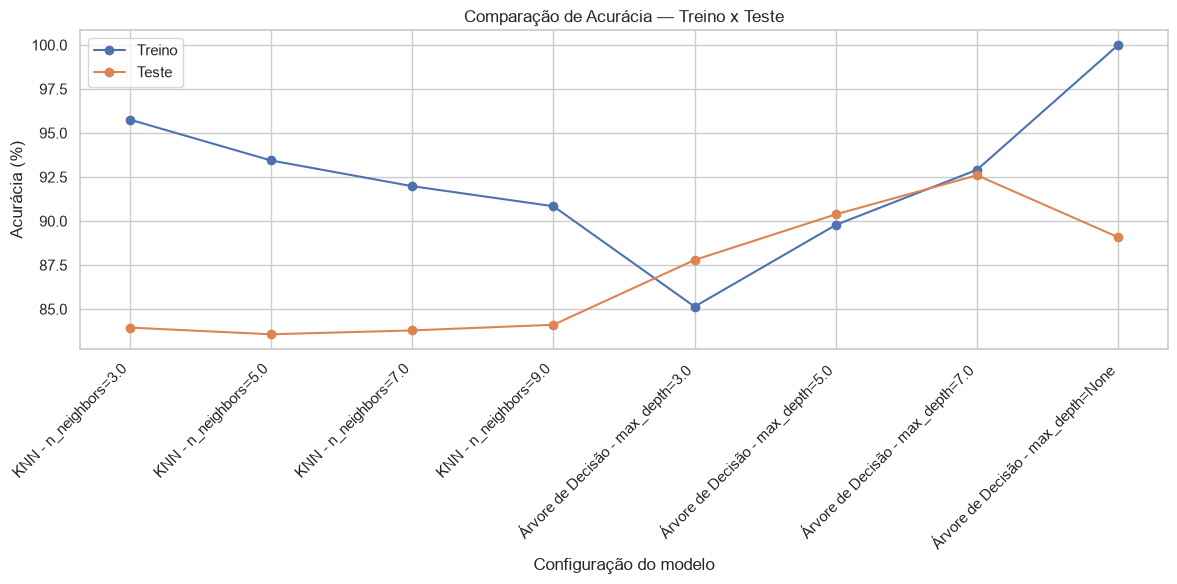

In [60]:
# Gráfico para comparar acurácia de treino e teste por configuração
# Usamos posições numéricas no eixo X para evitar erro com valores None/NaN.

plt.close("all")

df_plot_modelos = df_resultados_modelos_formatado.copy()

# Convertendo o valor do parâmetro para texto de forma segura
df_plot_modelos["valor_parametro_texto"] = (
    df_plot_modelos["valor_parametro"]
    .astype(object)
    .where(df_plot_modelos["valor_parametro"].notna(), "None")
    .astype(str)
)

# Criando o nome da configuração
df_plot_modelos["configuracao"] = (
    df_plot_modelos["modelo"].astype(str)
    + " - "
    + df_plot_modelos["parametro"].astype(str)
    + "="
    + df_plot_modelos["valor_parametro_texto"]
)

# Criando posições numéricas para o eixo X
posicoes_x = range(len(df_plot_modelos))

plt.figure(figsize=(12, 6))

plt.plot(
    posicoes_x,
    df_plot_modelos["acuracia_treino"],
    marker="o",
    label="Treino"
)

plt.plot(
    posicoes_x,
    df_plot_modelos["acuracia_teste"],
    marker="o",
    label="Teste"
)

plt.title("Comparação de Acurácia — Treino x Teste")
plt.xlabel("Configuração do modelo")
plt.ylabel("Acurácia (%)")
plt.xticks(
    ticks=posicoes_x,
    labels=df_plot_modelos["configuracao"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    pasta_graficos / "comparacao_acuracia_treino_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
df_resultados_modelos_formatado

,modelo,parametro,valor_parametro,acuracia_treino,acuracia_teste,precision_classe_1_teste,recall_classe_1_teste,f1_classe_1_teste,diferenca_treino_teste
0,KNN,n_neighbors,3.0,95.76,83.95,60.98,73.84,66.79,11.81
1,KNN,n_neighbors,5.0,93.44,83.57,59.98,74.82,66.58,9.87
2,KNN,n_neighbors,7.0,91.98,83.79,60.33,75.60,67.10,8.19
3,KNN,n_neighbors,9.0,90.84,84.11,61.04,75.67,67.57,6.73
4,Árvore de Decisão,max_depth,3.0,85.14,87.79,81.87,56.70,67.00,-2.65
5,Árvore de Decisão,max_depth,5.0,89.78,90.38,82.59,70.94,76.33,-0.60
6,Árvore de Decisão,max_depth,7.0,92.91,92.60,97.28,68.05,80.08,0.31
7,Árvore de Decisão,max_depth,NaN,100.00,89.08,73.51,78.28,75.82,10.92


In [62]:
# Selecionando a melhor configuração de cada modelo com base no F1-score da classe 1 no teste

melhor_knn = df_resultados_knn.sort_values(
    by="f1_classe_1_teste",
    ascending=False
).iloc[0]

melhor_arvore = df_resultados_arvore.sort_values(
    by="f1_classe_1_teste",
    ascending=False
).iloc[0]

print("Melhor configuração do KNN:")
print(melhor_knn)

print("\nMelhor configuração da Árvore de Decisão:")
print(melhor_arvore)

Melhor configuração do KNN:
modelo                              KNN
parametro                   n_neighbors
valor_parametro                       9
acuracia_treino                 0.90842
acuracia_teste                 0.841147
precision_classe_1_teste       0.610353
recall_classe_1_teste            0.7567
f1_classe_1_teste              0.675693
Name: 3, dtype: object

Melhor configuração da Árvore de Decisão:
modelo                      Árvore de Decisão
parametro                           max_depth
valor_parametro                           7.0
acuracia_treino                      0.929125
acuracia_teste                       0.925972
precision_classe_1_teste             0.972782
recall_classe_1_teste                0.680536
f1_classe_1_teste                     0.80083
Name: 2, dtype: object


## 5.3 Diagnóstico de overfitting

A comparação entre as métricas de treino e teste permitiu avaliar o comportamento dos modelos em diferentes configurações.

No KNN, valores menores de K tendem a ser mais sensíveis aos dados de treino, podendo capturar ruídos da base. Por isso, foram testados diferentes valores de `n_neighbors`, comparando o desempenho no treino e no teste.

Na Árvore de Decisão, a profundidade máxima teve impacto direto na complexidade do modelo. Árvores muito profundas podem apresentar desempenho elevado no treino, mas queda no teste, indicando overfitting. Já árvores muito rasas podem não aprender padrões suficientes.

Para este problema de risco de crédito, a escolha do melhor modelo não deve considerar apenas a acurácia geral. Como a classe mais importante é a classe `1`, correspondente aos clientes inadimplentes, métricas como recall e F1-score da classe 1 têm maior relevância para a decisão final.